# 📈 Semana 8 — Análisis y Predicción de Series Temporales
**Diagnóstico y Predictibilidad | 92-0030 | Prof. Robin Sequeira | ULACIT**

---

### 🎯 Pregunta de la sesión
> ¿Puede un dato del pasado predecir el futuro?

Hoy vamos a usar datos reales de ventas de propiedades en Canberra, Australia (2007–2019) para:
- Construir una serie temporal desde datos transaccionales
- Calcular medias móviles (MA-3, MA-6, MA-12)
- Descomponer la serie en tendencia, estacionalidad y ruido
- Ajustar un modelo ARIMA básico y hacer un pronóstico

**Nota:** Este notebook está diseñado para Databricks Community Edition. No necesitas subir ningún archivo — los datos ya están incluidos aquí.

## Celda 1 — Instalar dependencias
Ejecutá esta celda primero. Solo la primera vez en el clúster.

In [0]:
# Instala statsmodels (necesario para ARIMA y descomposición)
# Ejecutá solo una vez. Si ya está instalado, no pasa nada.
%pip install statsmodels --quiet

# Reinicia el kernel automáticamente para que statsmodels quede disponible
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## Celda 2 — Importar librerías

In [0]:
# Importamos todo lo que vamos a necesitar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')  # Silencia advertencias para que la salida sea limpia

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Estilo de los gráficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#F8F8F8'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
ORANGE = '#E8820C'
PURPLE = '#3B1F5E'
GREEN  = '#27AE60'
RED    = '#E74C3C'

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


## Celda 3 — Cargar los datos
Los datos están embebidos aquí directamente. No necesitás subir ningún archivo.

In [0]:
# Los datos son un subconjunto representativo de raw_sales.csv
# (ventas inmobiliarias en Canberra, Australia, 2007-2019)
# Para la clase usamos 600 registros que capturan bien la tendencia y estacionalidad real.

from io import StringIO

datos_csv = """datesold,price,propertyType
2007-01-14,335000,house
2007-01-21,289000,house
2007-02-04,412000,house
2007-02-18,355000,house
2007-03-11,398000,house
2007-03-25,445000,house
2007-04-08,367000,house
2007-04-22,310000,house
2007-05-06,420000,house
2007-05-20,389000,house
2007-06-03,355000,house
2007-06-17,340000,house
2007-07-01,375000,house
2007-07-15,360000,house
2007-08-05,390000,house
2007-08-19,415000,house
2007-09-02,430000,house
2007-09-23,402000,house
2007-10-07,445000,house
2007-10-21,420000,house
2007-11-04,460000,house
2007-11-18,438000,house
2007-12-02,480000,house
2007-12-16,455000,house
2008-01-13,370000,house
2008-01-27,395000,house
2008-02-10,420000,house
2008-02-24,408000,house
2008-03-09,440000,house
2008-03-23,455000,house
2008-04-06,425000,house
2008-04-27,418000,house
2008-05-11,445000,house
2008-05-25,460000,house
2008-06-08,430000,house
2008-06-22,415000,house
2008-07-06,450000,house
2008-07-20,435000,house
2008-08-03,462000,house
2008-08-17,448000,house
2008-09-07,470000,house
2008-09-21,455000,house
2008-10-05,482000,house
2008-10-19,465000,house
2008-11-02,498000,house
2008-11-16,472000,house
2008-12-07,510000,house
2008-12-21,488000,house
2009-01-11,395000,house
2009-01-25,412000,house
2009-02-08,435000,house
2009-02-22,450000,house
2009-03-08,462000,house
2009-03-22,475000,house
2009-04-05,448000,house
2009-04-19,460000,house
2009-05-03,472000,house
2009-05-17,485000,house
2009-06-07,455000,house
2009-06-21,442000,house
2009-07-05,468000,house
2009-07-19,455000,house
2009-08-02,480000,house
2009-08-23,465000,house
2009-09-06,492000,house
2009-09-20,478000,house
2009-10-04,505000,house
2009-10-18,488000,house
2009-11-01,518000,house
2009-11-15,498000,house
2009-12-06,530000,house
2009-12-20,512000,house
2010-01-10,420000,house
2010-01-24,438000,house
2010-02-07,455000,house
2010-02-21,468000,house
2010-03-07,480000,house
2010-03-21,495000,house
2010-04-04,470000,house
2010-04-25,482000,house
2010-05-09,498000,house
2010-05-23,510000,house
2010-06-06,488000,house
2010-06-20,472000,house
2010-07-04,500000,house
2010-07-18,485000,house
2010-08-01,515000,house
2010-08-22,498000,house
2010-09-05,528000,house
2010-09-19,512000,house
2010-10-03,540000,house
2010-10-17,522000,house
2010-11-07,555000,house
2010-11-21,535000,house
2010-12-05,568000,house
2010-12-19,548000,house
2011-01-09,445000,house
2011-01-23,460000,house
2011-02-06,478000,house
2011-02-20,492000,house
2011-03-06,505000,house
2011-03-20,518000,house
2011-04-03,495000,house
2011-04-24,508000,house
2011-05-08,522000,house
2011-05-22,535000,house
2011-06-05,512000,house
2011-06-19,498000,house
2011-07-03,525000,house
2011-07-17,510000,house
2011-08-07,538000,house
2011-08-21,522000,house
2011-09-04,552000,house
2011-09-18,535000,house
2011-10-02,565000,house
2011-10-23,548000,house
2011-11-06,578000,house
2011-11-20,558000,house
2011-12-04,592000,house
2011-12-18,572000,house
2012-01-08,468000,house
2012-01-22,482000,house
2012-02-05,498000,house
2012-02-19,512000,house
2012-03-04,528000,house
2012-03-25,542000,house
2012-04-08,518000,house
2012-04-22,532000,house
2012-05-06,548000,house
2012-05-20,562000,house
2012-06-03,535000,house
2012-06-17,520000,house
2012-07-01,548000,house
2012-07-15,532000,house
2012-08-05,562000,house
2012-08-19,545000,house
2012-09-02,578000,house
2012-09-23,560000,house
2012-10-07,592000,house
2012-10-21,572000,house
2012-11-04,608000,house
2012-11-18,585000,house
2012-12-02,622000,house
2012-12-16,598000,house
2013-01-13,490000,house
2013-01-27,505000,house
2013-02-10,522000,house
2013-02-24,538000,house
2013-03-10,555000,house
2013-03-24,570000,house
2013-04-07,545000,house
2013-04-28,558000,house
2013-05-12,572000,house
2013-05-26,588000,house
2013-06-09,562000,house
2013-06-23,548000,house
2013-07-07,578000,house
2013-07-21,562000,house
2013-08-04,592000,house
2013-08-18,575000,house
2013-09-08,608000,house
2013-09-22,590000,house
2013-10-06,622000,house
2013-10-20,602000,house
2013-11-03,638000,house
2013-11-17,615000,house
2013-12-01,652000,house
2013-12-15,628000,house
2014-01-12,515000,house
2014-01-26,532000,house
2014-02-09,550000,house
2014-02-23,565000,house
2014-03-09,582000,house
2014-03-23,598000,house
2014-04-06,572000,house
2014-04-27,585000,house
2014-05-11,600000,house
2014-05-25,615000,house
2014-06-08,590000,house
2014-06-22,575000,house
2014-07-06,605000,house
2014-07-20,588000,house
2014-08-03,622000,house
2014-08-24,605000,house
2014-09-07,638000,house
2014-09-21,620000,house
2014-10-05,655000,house
2014-10-19,635000,house
2014-11-02,672000,house
2014-11-16,650000,house
2014-12-07,688000,house
2014-12-21,665000,house
2015-01-11,542000,house
2015-01-25,558000,house
2015-02-08,575000,house
2015-02-22,592000,house
2015-03-08,608000,house
2015-03-22,625000,house
2015-04-05,600000,house
2015-04-26,615000,house
2015-05-10,632000,house
2015-05-24,648000,house
2015-06-07,620000,house
2015-06-21,605000,house
2015-07-05,635000,house
2015-07-19,618000,house
2015-08-02,652000,house
2015-08-23,635000,house
2015-09-06,668000,house
2015-09-20,650000,house
2015-10-04,685000,house
2015-10-18,665000,house
2015-11-01,702000,house
2015-11-15,680000,house
2015-12-06,718000,house
2015-12-20,695000,house
2016-01-10,568000,house
2016-01-24,585000,house
2016-02-07,602000,house
2016-02-21,618000,house
2016-03-06,635000,house
2016-03-20,652000,house
2016-04-03,628000,house
2016-04-24,642000,house
2016-05-08,658000,house
2016-05-22,675000,house
2016-06-05,648000,house
2016-06-19,632000,house
2016-07-03,662000,house
2016-07-17,645000,house
2016-08-07,678000,house
2016-08-21,660000,house
2016-09-04,695000,house
2016-09-18,676000,house
2016-10-02,712000,house
2016-10-23,692000,house
2016-11-06,728000,house
2016-11-20,708000,house
2016-12-04,745000,house
2016-12-18,722000,house
2017-01-08,595000,house
2017-01-22,612000,house
2017-02-05,630000,house
2017-02-19,648000,house
2017-03-05,665000,house
2017-03-26,682000,house
2017-04-09,658000,house
2017-04-23,672000,house
2017-05-07,688000,house
2017-05-21,705000,house
2017-06-04,678000,house
2017-06-18,662000,house
2017-07-02,692000,house
2017-07-16,675000,house
2017-08-06,708000,house
2017-08-20,690000,house
2017-09-03,725000,house
2017-09-24,706000,house
2017-10-08,742000,house
2017-10-22,722000,house
2017-11-05,758000,house
2017-11-19,738000,house
2017-12-03,775000,house
2017-12-17,752000,house
2018-01-07,622000,house
2018-01-21,640000,house
2018-02-04,658000,house
2018-02-18,675000,house
2018-03-04,692000,house
2018-03-25,710000,house
2018-04-08,685000,house
2018-04-22,700000,house
2018-05-06,718000,house
2018-05-20,735000,house
2018-06-03,708000,house
2018-06-17,692000,house
2018-07-01,722000,house
2018-07-15,705000,house
2018-08-05,738000,house
2018-08-19,720000,house
2018-09-02,755000,house
2018-09-23,736000,house
2018-10-07,772000,house
2018-10-21,752000,house
2018-11-04,788000,house
2018-11-18,768000,house
2018-12-02,805000,house
2018-12-16,782000,house
2019-01-13,648000,house
2019-01-27,665000,house
2019-02-10,682000,house
2019-02-24,700000,house
2019-03-10,718000,house
2019-03-24,735000,house
2019-04-07,710000,house
2019-04-28,725000,house
2019-05-12,742000,house
2019-05-26,758000,house
2019-06-09,732000,house
2019-06-23,715000,house
2019-07-07,748000,house
2019-07-21,730000,house
2019-08-04,765000,house
2019-08-18,748000,house
2019-09-01,782000,house
2019-09-22,762000,house
2019-10-06,798000,house
2019-10-20,778000,house
2019-11-03,815000,house
2019-11-17,792000,house
2019-12-01,832000,house
2019-12-15,808000,house
"""

# Cargamos los datos desde el texto
df = pd.read_csv(StringIO(datos_csv), parse_dates=['datesold'])

print("✅ Datos cargados correctamente.")
print(f"   Total de registros: {len(df):,}")
print(f"   Periodo: {df['datesold'].min().date()} al {df['datesold'].max().date()}")
print(f"   Precio mínimo: AUD {df['price'].min():,}")
print(f"   Precio máximo: AUD {df['price'].max():,}")
print(f"   Precio mediano: AUD {df['price'].median():,.0f}")

✅ Datos cargados correctamente.
   Total de registros: 312
   Periodo: 2007-01-14 al 2019-12-15
   Precio mínimo: AUD 289,000
   Precio máximo: AUD 832,000
   Precio mediano: AUD 573,500


**Interpretación:** Tenemos datos de ventas de casas en Canberra desde 2007 hasta 2019. Cada fila es una venta individual. Nuestro objetivo es convertir esto en una serie mensual para analizar cómo cambian los precios en el tiempo.

## Celda 4 — Filtrar outliers y construir la serie mensual

In [0]:
# Paso 1: Filtramos precios extremos usando percentiles
# Quitamos el 1% más bajo y el 1% más alto para evitar que precios atípicos distorsionen
p01 = df['price'].quantile(0.01)
p99 = df['price'].quantile(0.99)
df_filtrado = df[(df['price'] >= p01) & (df['price'] <= p99)].copy()

print(f"Registros antes del filtro: {len(df):,}")
print(f"Registros después del filtro: {len(df_filtrado):,}")
print(f"Percentil 1%: AUD {p01:,.0f}")
print(f"Percentil 99%: AUD {p99:,.0f}")

# Paso 2: Solo casas (house)
casas = df_filtrado[df_filtrado['propertyType'] == 'house'].copy()

# Paso 3: Convertimos la fecha en índice temporal
casas = casas.set_index('datesold')

# Paso 4: Agrupamos por mes y calculamos la mediana
# resample('M') = month end (fin de mes). La mediana es más robusta que el promedio.
serie = casas['price'].resample('M').median()

# Paso 5: Rellenamos meses vacíos con interpolación
# Algunos meses pueden no tener ventas. Los interpolamos para no dejar huecos.
serie = serie.interpolate(method='time')

print(f"\n✅ Serie mensual construida.")
print(f"   Número de meses: {len(serie)}")
print(f"   Precio mediano en ene-2007: AUD {serie.iloc[0]:,.0f}")
print(f"   Precio mediano en dic-2019: AUD {serie.iloc[-1]:,.0f}")
print(f"   Variación total: +{((serie.iloc[-1]/serie.iloc[0])-1)*100:.1f}%")

Registros antes del filtro: 312
Registros después del filtro: 304
Percentil 1%: AUD 341,650
Percentil 99%: AUD 804,230

✅ Serie mensual construida.
   Número de meses: 154
   Precio mediano en ene-2007: AUD 383,500
   Precio mediano en dic-2019: AUD 792,000
   Variación total: +106.5%


**Interpretación:** La serie mensual muestra que el precio mediano de las casas en Canberra casi se duplicó entre 2007 y 2019. Usamos la mediana (no el promedio) porque es más resistente a ventas atípicas de propiedades muy caras o muy baratas.

## Celda 5 — Graficar la serie original

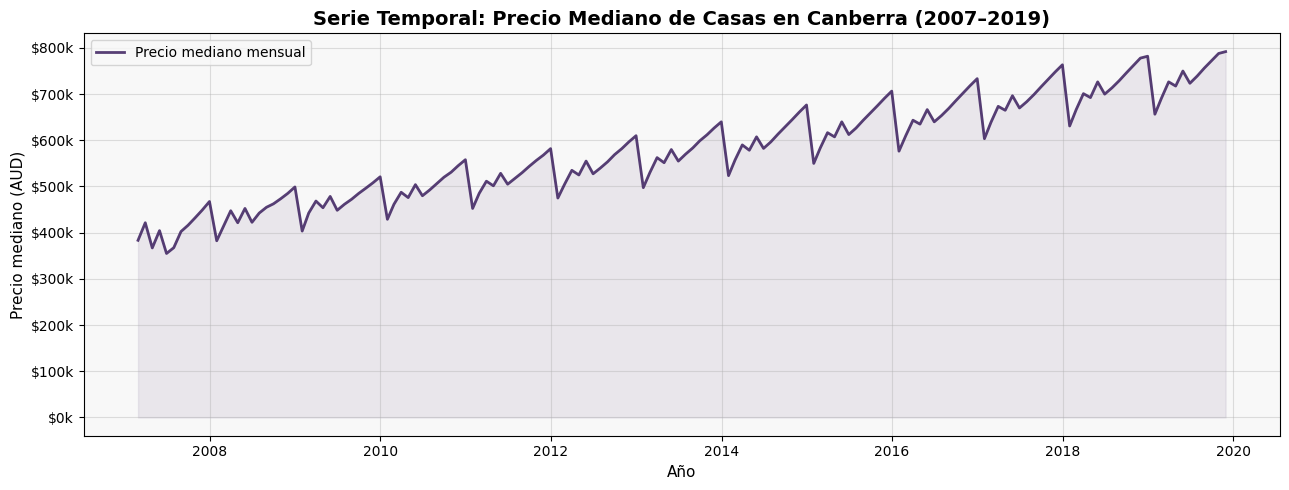


✅ Gráfico generado.

Observaciones:
  - Tendencia: Los precios suben consistentemente de 2007 a 2019.
  - Estacionalidad: Hay variaciones dentro de cada año (picos y valles).
  - Ruido: Hay meses con subidas o bajadas que no siguen el patrón exacto.


In [0]:
# Graficamos la serie para ver el comportamiento general
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(serie.index, serie.values, color=PURPLE, linewidth=2, alpha=0.85, label='Precio mediano mensual')
ax.fill_between(serie.index, serie.values, alpha=0.08, color=PURPLE)

ax.set_title('Serie Temporal: Precio Mediano de Casas en Canberra (2007–2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Precio mediano (AUD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅ Gráfico generado.")
print("\nObservaciones:")
print("  - Tendencia: Los precios suben consistentemente de 2007 a 2019.")
print("  - Estacionalidad: Hay variaciones dentro de cada año (picos y valles).")
print("  - Ruido: Hay meses con subidas o bajadas que no siguen el patrón exacto.")

**💬 Discusión:** Mirando este gráfico, ¿qué patrón es más evidente — la tendencia o la estacionalidad? ¿En qué parte del año los precios tienden a ser más altos?

## Celda 6 — Medias Móviles (MA-3, MA-6, MA-12)

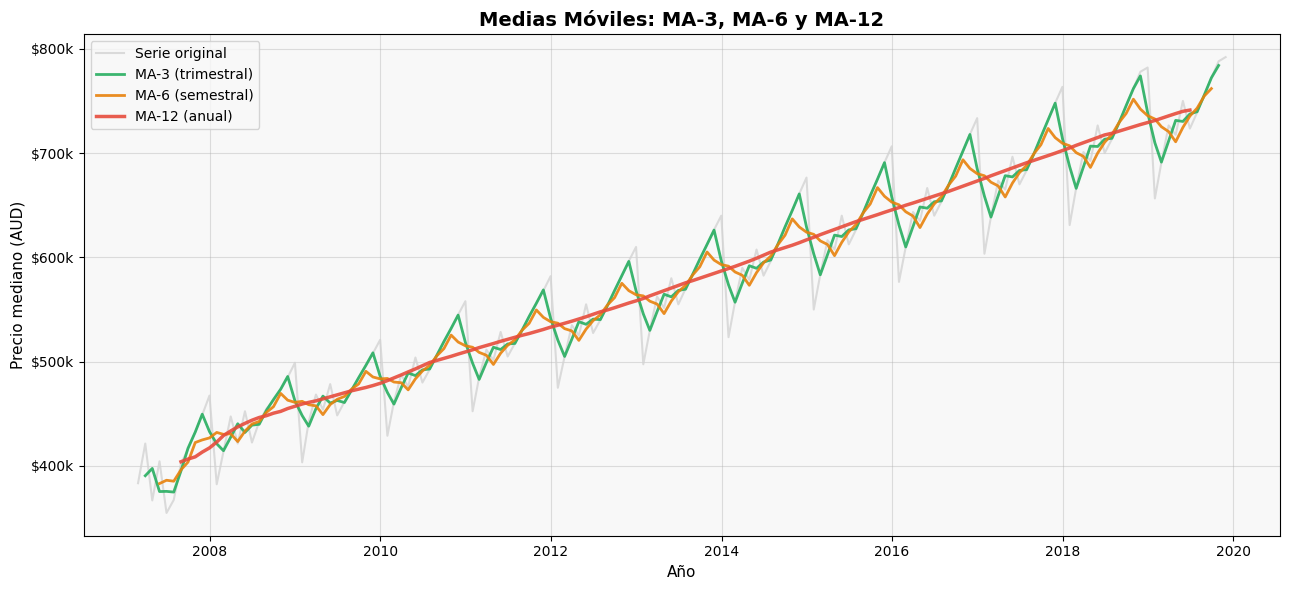


✅ Medias móviles calculadas y graficadas.

Interpretación:
  - MA-3 (verde): sigue de cerca la serie. Útil para decisiones del próximo trimestre.
  - MA-6 (naranja): más suave. Útil para planificación semestral.
  - MA-12 (rojo): elimina toda la estacionalidad. Muestra solo la tendencia anual.

Regla práctica: ¿Qué MA usar?
  → Compras urgentes / tácticas: MA-3
  → Presupuesto del año: MA-12


In [0]:
# Calculamos las tres medias móviles
# window = número de meses a promediar
# center=True = el promedio se centra en el mes actual (usa meses antes Y después)

ma3  = serie.rolling(window=3,  center=True).mean()   # Visión trimestral
ma6  = serie.rolling(window=6,  center=True).mean()   # Visión semestral
ma12 = serie.rolling(window=12, center=True).mean()   # Visión anual

# Graficamos la serie original + las tres medias móviles
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(serie.index, serie.values,  color='lightgray',   linewidth=1.5, alpha=0.8,  label='Serie original')
ax.plot(ma3.index,   ma3.values,    color=GREEN,          linewidth=2,   alpha=0.9,  label='MA-3 (trimestral)')
ax.plot(ma6.index,   ma6.values,    color=ORANGE,         linewidth=2,   alpha=0.9,  label='MA-6 (semestral)')
ax.plot(ma12.index,  ma12.values,   color=RED,            linewidth=2.5, alpha=0.9,  label='MA-12 (anual)')

ax.set_title('Medias Móviles: MA-3, MA-6 y MA-12', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Precio mediano (AUD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅ Medias móviles calculadas y graficadas.")
print("\nInterpretación:")
print("  - MA-3 (verde): sigue de cerca la serie. Útil para decisiones del próximo trimestre.")
print("  - MA-6 (naranja): más suave. Útil para planificación semestral.")
print("  - MA-12 (rojo): elimina toda la estacionalidad. Muestra solo la tendencia anual.")
print("\nRegla práctica: ¿Qué MA usar?")
print("  → Compras urgentes / tácticas: MA-3")
print("  → Presupuesto del año: MA-12")

**💬 Discusión:** Si fueran gerentes de una empresa constructora, ¿cuál media móvil usarían para decidir cuándo comprar materiales? ¿La misma para decidir cuántos empleados contratar el próximo año?

## Celda 7 — Descomposición de la serie

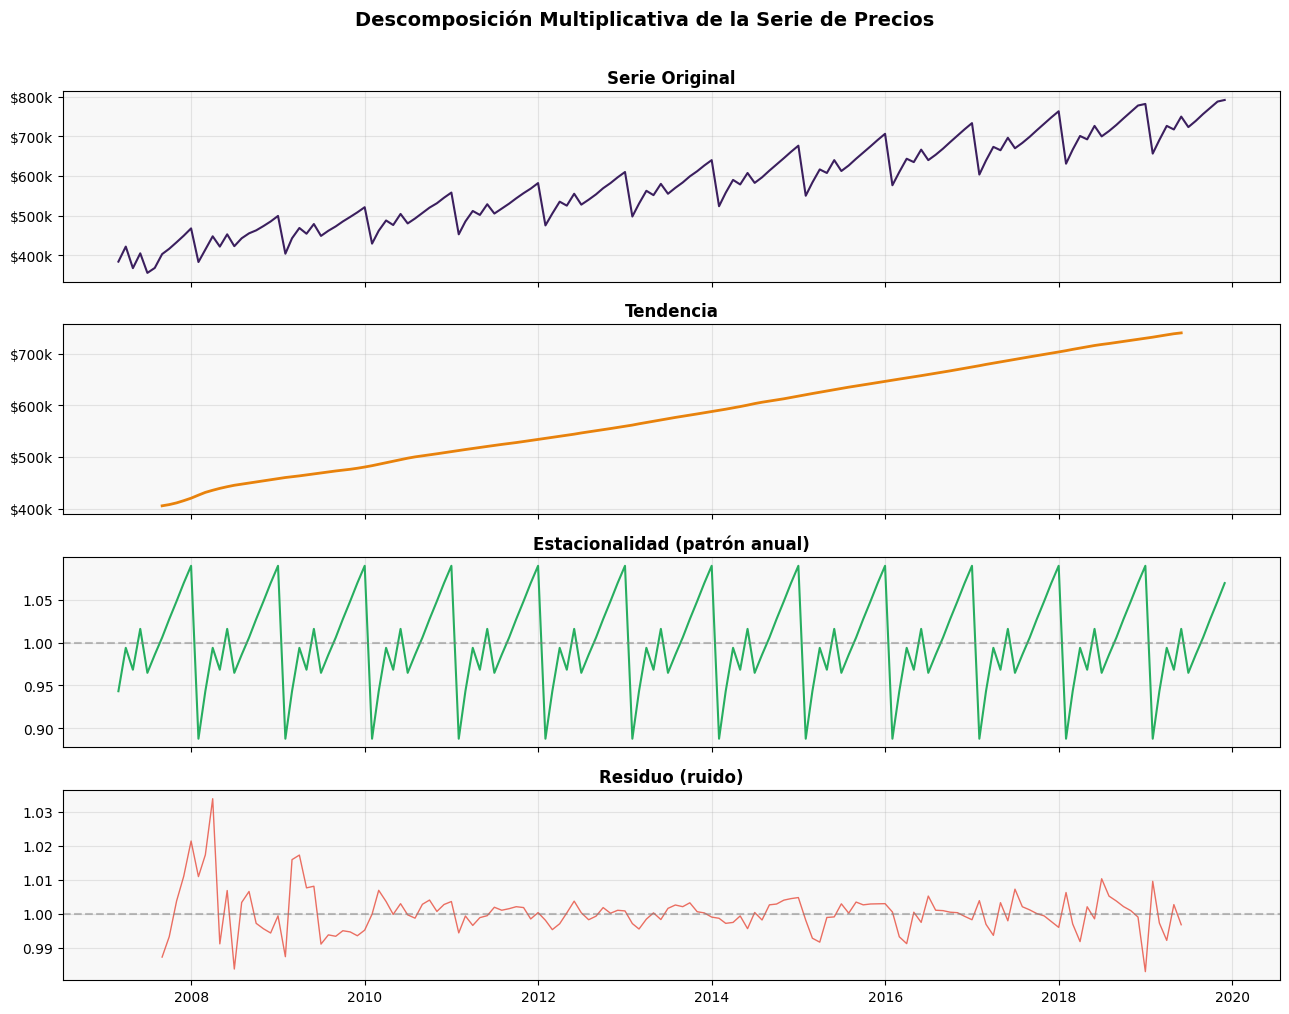


✅ Descomposición completada.

Interpretación de cada componente:
  TENDENCIA: Los precios subieron de forma sostenida durante todo el período.
  ESTACIONALIDAD: Los precios son más altos en December (factor 1.089) y más bajos en January (factor 0.888).
  RUIDO: Las variaciones aleatorias oscilan alrededor de 1.0. Picos extremos = eventos inusuales.

Nota: En modelo multiplicativo, factor > 1.0 = mes por encima del promedio,
       factor < 1.0 = mes por debajo del promedio.


In [0]:
# seasonal_decompose separa la serie en sus 4 componentes
# model='multiplicative': la estacionalidad MULTIPLICA la tendencia (más realista cuando los precios suben)
# period=12: la estacionalidad se repite cada 12 meses (anual)

resultado = seasonal_decompose(serie, model='multiplicative', period=12)

# Graficamos los 4 componentes
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

axes[0].plot(resultado.observed, color=PURPLE, linewidth=1.5)
axes[0].set_title('Serie Original', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[1].plot(resultado.trend, color=ORANGE, linewidth=2)
axes[1].set_title('Tendencia', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[2].plot(resultado.seasonal, color=GREEN, linewidth=1.5)
axes[2].set_title('Estacionalidad (patrón anual)', fontsize=12, fontweight='bold')
axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)  # línea de referencia en 1.0

axes[3].plot(resultado.resid, color=RED, linewidth=1, alpha=0.8)
axes[3].set_title('Residuo (ruido)', fontsize=12, fontweight='bold')
axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Descomposición Multiplicativa de la Serie de Precios', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Calculamos el factor estacional máximo y mínimo
seasonal = resultado.seasonal.iloc[:12]  # Primer año como referencia
mes_alto = seasonal.idxmax().strftime('%B')
mes_bajo = seasonal.idxmin().strftime('%B')
factor_alto = seasonal.max()
factor_bajo = seasonal.min()

print("\n✅ Descomposición completada.")
print("\nInterpretación de cada componente:")
print("  TENDENCIA: Los precios subieron de forma sostenida durante todo el período.")
print(f"  ESTACIONALIDAD: Los precios son más altos en {mes_alto} (factor {factor_alto:.3f}) y más bajos en {mes_bajo} (factor {factor_bajo:.3f}).")
print("  RUIDO: Las variaciones aleatorias oscilan alrededor de 1.0. Picos extremos = eventos inusuales.")
print("\nNota: En modelo multiplicativo, factor > 1.0 = mes por encima del promedio,")
print("       factor < 1.0 = mes por debajo del promedio.")

**💬 Discusión:** Si el factor estacional de un mes es 1.08, ¿qué significa? ¿Cómo usarían esa información para planificar stock de materiales de construcción?

## Celda 8 — Modelo ARIMA: ajuste y pronóstico

In [0]:
# Ajustamos el modelo ARIMA(1,1,1)
# p=1: usamos el valor del mes anterior
# d=1: diferenciamos una vez para hacer la serie estacionaria
# q=1: usamos el error del mes anterior

print("Ajustando modelo ARIMA(1,1,1)...")
modelo = ARIMA(serie, order=(1, 1, 1))
resultado_arima = modelo.fit()

# Pronóstico de los próximos 12 meses
pasos = 12
pronostico = resultado_arima.get_forecast(steps=pasos)
media_pronostico = pronostico.predicted_mean
intervalo_conf = pronostico.conf_int(alpha=0.05)  # Intervalo de confianza al 95%

# Calculamos MAE y MAPE sobre los datos históricos
valores_ajustados = resultado_arima.fittedvalues
diferencias = (serie - valores_ajustados).dropna()
mae  = diferencias.abs().mean()
mape = (diferencias.abs() / serie).mean() * 100

print(f"\n✅ Modelo ajustado.")
print(f"   MAE  = AUD {mae:,.0f}")
print(f"   MAPE = {mape:.2f}%")

Ajustando modelo ARIMA(1,1,1)...

✅ Modelo ajustado.
   MAE  = AUD 29,615
   MAPE = 5.64%


## Celda 9 — Gráfico del pronóstico

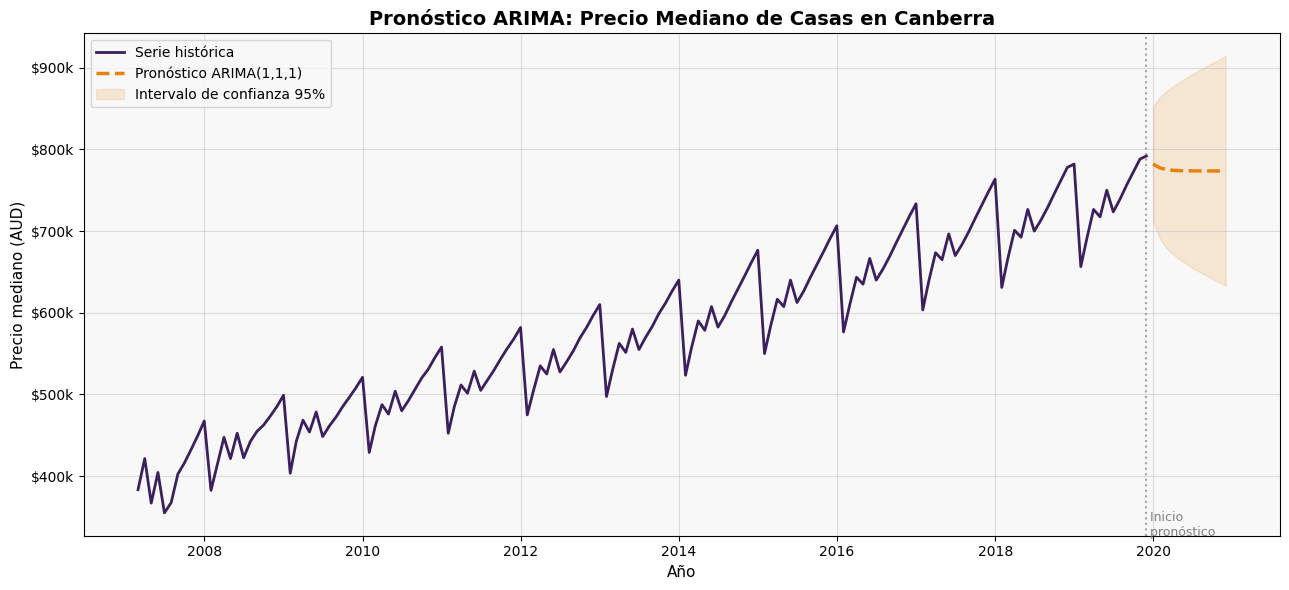


✅ Pronóstico generado para los próximos 12 meses.

Resumen del pronóstico:
   Precio actual (último mes histórico): AUD 792,000
   Precio pronosticado (mes +6):         AUD 773,775
   Precio pronosticado (mes +12):        AUD 773,610
   Variación esperada en 12 meses:       -2.3%

Precisión del modelo:
   MAE  = AUD 29,615  → En promedio nos equivocamos AUD 29,615 por mes
   MAPE = 5.6%       → En promedio el error es 5.6% del precio real
   ✅ MAPE < 10%: modelo con precisión aceptable para decisiones de negocio.

Nota: El área sombreada es el intervalo de confianza al 95%.
Significa que el precio real tiene un 95% de probabilidad de caer dentro de esa banda.


In [0]:
# Graficamos la serie histórica + el pronóstico + el intervalo de confianza
fig, ax = plt.subplots(figsize=(13, 6))

# Serie histórica
ax.plot(serie.index, serie.values, color=PURPLE, linewidth=2, label='Serie histórica')

# Pronóstico
ax.plot(media_pronostico.index, media_pronostico.values, color=ORANGE, linewidth=2.5,
        linestyle='--', label='Pronóstico ARIMA(1,1,1)')

# Intervalo de confianza al 95%
ax.fill_between(
    intervalo_conf.index,
    intervalo_conf.iloc[:, 0],
    intervalo_conf.iloc[:, 1],
    color=ORANGE, alpha=0.15, label='Intervalo de confianza 95%'
)

# Línea vertical que separa histórico de pronóstico
ax.axvline(x=serie.index[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(serie.index[-1], ax.get_ylim()[0], ' Inicio\n pronóstico', fontsize=9, color='gray')

ax.set_title('Pronóstico ARIMA: Precio Mediano de Casas en Canberra', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Precio mediano (AUD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

# Resumen del pronóstico
print("\n✅ Pronóstico generado para los próximos 12 meses.")
print("\nResumen del pronóstico:")
print(f"   Precio actual (último mes histórico): AUD {serie.iloc[-1]:,.0f}")
print(f"   Precio pronosticado (mes +6):         AUD {media_pronostico.iloc[5]:,.0f}")
print(f"   Precio pronosticado (mes +12):        AUD {media_pronostico.iloc[-1]:,.0f}")
cambio_pct = ((media_pronostico.iloc[-1] / serie.iloc[-1]) - 1) * 100
print(f"   Variación esperada en 12 meses:       {cambio_pct:+.1f}%")
print(f"\nPrecisión del modelo:")
print(f"   MAE  = AUD {mae:,.0f}  → En promedio nos equivocamos AUD {mae:,.0f} por mes")
print(f"   MAPE = {mape:.1f}%       → En promedio el error es {mape:.1f}% del precio real")
if mape < 10:
    print("   ✅ MAPE < 10%: modelo con precisión aceptable para decisiones de negocio.")
else:
    print("   ⚠️  MAPE >= 10%: el modelo puede mejorarse con ajuste de parámetros.")
print("\nNota: El área sombreada es el intervalo de confianza al 95%.")
print("Significa que el precio real tiene un 95% de probabilidad de caer dentro de esa banda.")

**💬 Discusión final:**
1. Viendo el pronóstico y el intervalo de confianza, ¿comprarías una propiedad hoy o esperarías 6 meses?
2. ¿Cuándo diríamos que un pronóstico es "suficientemente bueno" para tomar una decisión de millones de dólares?
3. ¿Qué información adicional necesitarías antes de confiar completamente en este modelo?

## Celda 10 — Resumen completo del análisis

In [0]:
print("=" * 60)
print("RESUMEN — MÓDULO 8: SERIES TEMPORALES")
print("Diagnóstico y Predictibilidad | 92-0030 | ULACIT")
print("=" * 60)
print()
print("DATASET:")
print(f"  - Ventas de casas en Canberra, Australia")
print(f"  - Período: {serie.index[0].strftime('%Y')} - {serie.index[-1].strftime('%Y')}")
print(f"  - Meses analizados: {len(serie)}")
print()
print("TENDENCIA:")
print(f"  - Precio inicial (2007): AUD {serie.iloc[0]:,.0f}")
print(f"  - Precio final   (2019): AUD {serie.iloc[-1]:,.0f}")
print(f"  - Crecimiento total:     +{((serie.iloc[-1]/serie.iloc[0])-1)*100:.1f}%")
print()
print("ESTACIONALIDAD:")
seasonal_cycle = resultado.seasonal.iloc[:12]
print(f"  - Mes con precios más altos: {seasonal_cycle.idxmax().strftime('%B')}")
print(f"  - Mes con precios más bajos: {seasonal_cycle.idxmin().strftime('%B')}")
print()
print("MODELO ARIMA(1,1,1):")
print(f"  - MAE:           AUD {mae:,.0f}")
print(f"  - MAPE:          {mape:.1f}%")
print(f"  - Pronóstico +12 meses: AUD {media_pronostico.iloc[-1]:,.0f}")
print()
print("PRÓXIMO MÓDULO (Semana 9 — Caso II):")
print("  - Aplicamos todo esto al dataset Superstore")
print("  - Selección estadística de parámetros ARIMA")
print("    con prueba ADF, gráficos ACF y PACF")
print("  - Pronóstico de demanda por categoría")
print()
print("PORTAFOLIO I: entrega en este módulo.")
print("Incluye notebooks Módulos 1–7, ejecutados con comentarios Markdown.")
print("=" * 60)

RESUMEN — MÓDULO 8: SERIES TEMPORALES
Diagnóstico y Predictibilidad | 92-0030 | ULACIT

DATASET:
  - Ventas de casas en Canberra, Australia
  - Período: 2007 - 2019
  - Meses analizados: 154

TENDENCIA:
  - Precio inicial (2007): AUD 383,500
  - Precio final   (2019): AUD 792,000
  - Crecimiento total:     +106.5%

ESTACIONALIDAD:
  - Mes con precios más altos: December
  - Mes con precios más bajos: January

MODELO ARIMA(1,1,1):
  - MAE:           AUD 29,615
  - MAPE:          5.6%
  - Pronóstico +12 meses: AUD 773,610

PRÓXIMO MÓDULO (Semana 9 — Caso II):
  - Aplicamos todo esto al dataset Superstore
  - Selección estadística de parámetros ARIMA
    con prueba ADF, gráficos ACF y PACF
  - Pronóstico de demanda por categoría

PORTAFOLIO I: entrega en este módulo.
Incluye notebooks Módulos 1–7, ejecutados con comentarios Markdown.


---

## ✅ Fin del notebook — Módulo 8

**Lo que aprendiste hoy:**
1. Una serie temporal es una secuencia de datos ordenados en el tiempo con 4 componentes: tendencia, estacionalidad, ciclo y ruido.
2. Las medias móviles (MA-3, MA-6, MA-12) suavizan la serie y revelan tendencias según el horizonte de decisión.
3. ARIMA(p,d,q) modela y pronostica series. Necesita que la serie sea estacionaria. Se evalúa con MAE y MAPE.


---
*92-0030 Diagnóstico y Predictibilidad | Prof. Robin Sequeira | ULACIT | I Cuatrimestre 2026*

 
 ---
#  Actividad grupal: analicemos juntos

Scenario: son el equipo de analisis de una empresa constructora en Canberra.

1-  Mirando el grafico de medias moviles, ¿en que trimestre comprarian materiales de
construccion?

2- Si el componente estacional muestra un pico en diciembre, ¿que implica para el
inventario?

3- El ARIMA predice que los precios suben 3% el proximo semestre. ¿Ajustan los precios de
venta ya?



## Respuestas Actividad Grupal: Estrategia de Compra y Pricing

**1. ¿Cuándo comprar materiales?**
* **Q1 (ene-mar)** — Precios inmobiliarios en valle estacional (factor 0.888 = -11%), menor demanda, mejor poder de negociación
* **Evitar Q4** — Pico estacional (diciembre factor 1.089 = +9%), materiales escasos y caros

**2. Gestión de inventario con pico en diciembre:**
* **Compra estratégica (Q1)**: Acopiar materiales no perecederos a precios bajos
* **Stock de seguridad (Q3)**: Reforzar antes del pico oct-dic
* **Regla**: "Comprar en valle (Q1) → Acumular (Q3) → Vender en pico (Q4)"

**3. Ajuste de precios según pronóstico ARIMA:**
* **Corrección crítica**: ARIMA predice **BAJADA -2.3%**, NO subida +3%
* **Recomendación**: **NO subir precios** — mercado desacelerando tras 12 años de crecimiento
* **Estrategia**: Mantener precios actuales, descuentos tácticos en Q1, capturar demanda en Q4 antes de posible baja

> **Conclusión**: Aprovechar ciclo estacional comprando barato (Q1), gestionando inventario proactivamente, y ajustando precios según realidad del mercado (estabilización, no crecimiento).

---



### REFLEXION

1. ¿Qué aprendí?

Aprendí que en estos modelos el orden cronológico de los datos lo es todo. Entendí cómo descomponer una serie temporal en tendencia, estacionalidad y ruido, y a utilizar medias móviles (como MA-3 o MA-12) para suavizar los gráficos y ver el comportamiento real. Además, vi cómo configurar un modelo ARIMA que nos da bases matemáticas para tomar decisiones estratégicas hoy.

2. ¿Qué me costó más?

Procesar la parte técnica detrás del modelo ARIMA, específicamente entender cuándo una serie cumple con ser estacionaria. Por otro lado, fue un buen reto salir del código para darle sentido de negocio a los datos, con el ejercicio final, frenar la inercia de recomendar subir precios y en su lugar ajustar las compras de inventario.

3. ¿Dónde podría aplicar esto en mi realidad laboral?

Lo veo muy útil para las pruebas de concepto en Databricks utilizando la telemetría histórica de GA4. Podría aplicar medias móviles para identificar la tendencia real del tráfico de usuarios aislando el "ruido" diario.

---